## 📖 What this notebook does

**Goal:** Formalise the "segment-first, classify-second" idea from Notebook 5 into a clean, reproducible, multi-city pipeline and evaluate it rigorously using Leave-One-City-Out (LOCO) cross-validation across four European cities.

---

### How is this different from Notebook 5?

Notebook 5 *introduced* the concept and prototyped it on Bologna (one city, binary classification). This notebook:

- Scales to **four cities** (Riga, Utrecht, Vilnius, Warsaw)
- Uses a **three-class** target (other / sidewalk / street) instead of binary
- Is structured as a **clean, reproducible pipeline** with global constants and reusable functions
- Runs a full **LOCO evaluation** with a summary table
- Includes a complete **end-to-end inference helper** (`segment_first_classify_second()`) ready for new data

> **Note:** Bologna is excluded here because its version of the `.laz` file lacks the pre-computed geometric dimensions required for this stage.

---

### The pipeline in one sentence

*Sample → compute point-level geometry → group into segments → enrich each segment with its neighbors' statistics → train a Random Forest on segment features → evaluate across unseen cities.*

---

### Steps at a glance

| Section | What happens |
|---|---|
| **Environment setup** | Imports, reproducible seed, shared constants (sample size, voxel size, class targets) |
| **Load all cities** | Read `.laz` files for Riga, Utrecht, Vilnius, Warsaw; print class counts |
| **Visualise labels** | 2-D XY scatter for Riga coloured by class (sanity check) |
| **Build segmentation** | `build_city_segment_table()` runs the full per-city pipeline: geometry → superpoints → context features → labels |
| **Align features** | Find the columns common to all cities; exclude raw X/Y to avoid spatial overfitting |
| **LOCO training** | For each held-out city: train Random Forest (250 trees, `balanced_subsample`) on the other 3; evaluate; collect metrics |
| **LOCO summary** | Table of balanced accuracy, macro F1, weighted F1 per fold; list any skipped folds |
| **End-to-end inference** | `segment_first_classify_second()` wraps everything: input a LAS file, output a DataFrame with predicted segment labels |
| **Riga deep-dive** | Full inference on Riga; confusion matrix; top-15 misclassification pairs |

---

### Key functions in this notebook

| Function | What it does |
|---|---|
| `build_city_segment_table(las, city_name)` | Runs the full pipeline for one city: sample → geometry → segments → context → labels |
| `missing_classes(df, col, required)` | Safety check: returns any required class codes missing from `df[col]` |
| `segment_first_classify_second(las, city, clf, feature_cols)` | End-to-end inference: takes a raw LAS, returns predictions |

---

### Key concepts to understand

**`balanced_subsample` class weighting** — for each tree in the Random Forest, scikit-learn draws a bootstrap sample *balanced across classes*. This is critical here because "other" points dominate by count (often 80 %+), and without this the model simply predicts "other" for everything and still scores well on raw accuracy.

**Context features** — each superpoint is enriched with statistics (mean, std, min, max) of its 8 nearest neighboring superpoints. This means the classifier can see not just "what does this segment look like?" but also "what does the area around it look like?" — crucial for distinguishing pavements from roads based on relative position and surrounding geometry.

**Common feature alignment** — different cities were scanned with different LiDAR equipment and may have slightly different sets of pre-computed columns. Before running LOCO we intersect the column sets → only features available in *every* city are used. This prevents training failures and ensures fair comparisons.

**LOCO evaluation** — the strictest generalisation test here. Each fold is: *train on 3 completely different cities, test on the 4th*. No city's data is shared between train and test. If the macro F1 is high, the model has learned geometry, not city-specific patterns.

**Misclassification transitions** — after inference, we group predictions by (true label → predicted label) and sort by frequency. The most common wrong transitions (e.g., sidewalk predicted as other) directly indicate where the model needs improvement.

---

### Outputs you'll see
- Per-city class distribution counts (data quality check)
- 2-D label scatter plot for Riga
- Console log of segmentation progress per city (point counts, segment counts)
- Common feature columns list
- LOCO summary table: `held_out_city` | `n_train_segments` | `n_test_segments` | `balanced_acc` | `macro_f1` | `weighted_f1`
- Skipped-fold table (if any city lacks required classes)
- Riga end-to-end inference: classification report + confusion matrix (plot)
- Top-15 misclassification transitions (true → predicted with counts)

# Segment-first, classify-second (LiDAR)

This notebook starts a new workflow where we first produce geometric segments (superpoints/regions), then classify those segments.

Goal: improve cross-city robustness by using **contextual segment features** rather than pointwise-only prediction.

## 1) Environment Setup and Reproducibility

- Import required libraries
- Set random seeds
- Define shared constants and paths

In [4]:
import os
import sys
import random
from pathlib import Path

import laspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

WORKSPACE_ROOT = Path.cwd()
if not (WORKSPACE_ROOT / "src").exists() and (WORKSPACE_ROOT.parent / "src").exists():
    WORKSPACE_ROOT = WORKSPACE_ROOT.parent
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

import src.carriageway_focus_utils as cfu

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = Path("/media/HDD_disk/james/lidar_REALLOCATE")
N_SAMPLE_PER_CITY = 250_000

TARGET_CLASSES = {0: "other", 2: "sidewalk", 11: "street"}
CLASS_ORDER = [0, 2, 11]

# Segment controls
VOXEL_SIZE = 0.6
MIN_POINTS_PER_SEG = 8
N_CONTEXT_NEIGHBORS = 8

print("Seed:", SEED)
print("Workspace:", WORKSPACE_ROOT)
print("Data path:", DATA_PATH)

Seed: 42
Workspace: /media/M2_disk/james/REALLOCATE/lidar_sidewalks
Data path: /media/HDD_disk/james/lidar_REALLOCATE


## 2) Load Dataset and Define Paths

Load city LAS files and keep only cities with required class support for LOCO.

In [5]:
CITY_FILES = {
    "Riga": DATA_PATH / "riga.laz",
    "Utrecht": DATA_PATH / "utrecht.laz",
    "Vilnius": DATA_PATH / "vilnius.laz",
    "Warsaw": DATA_PATH / "warsaw.laz",
}

city_las = {name: laspy.read(path) for name, path in CITY_FILES.items()}
print("Loaded cities:", list(city_las.keys()))

for name, las in city_las.items():
    classes, counts = np.unique(np.asarray(las.classification), return_counts=True)
    c = dict(zip(classes.tolist(), counts.tolist()))
    print(f"{name}: class-0={c.get(0,0):,}, class-2={c.get(2,0):,}, class-11={c.get(11,0):,}")

Loaded cities: ['Riga', 'Utrecht', 'Vilnius', 'Warsaw']
Riga: class-0=8,916,701, class-2=1,750,164, class-11=2,574,596
Utrecht: class-0=24,767,576, class-2=0, class-11=0
Vilnius: class-0=0, class-2=2,738,424, class-11=3,909,593
Warsaw: class-0=8,390, class-2=2,591,247, class-11=2,874,303


## 3) Visualize Sample Points and Labels

Quick 2D sanity check using sampled XY points colored by class.

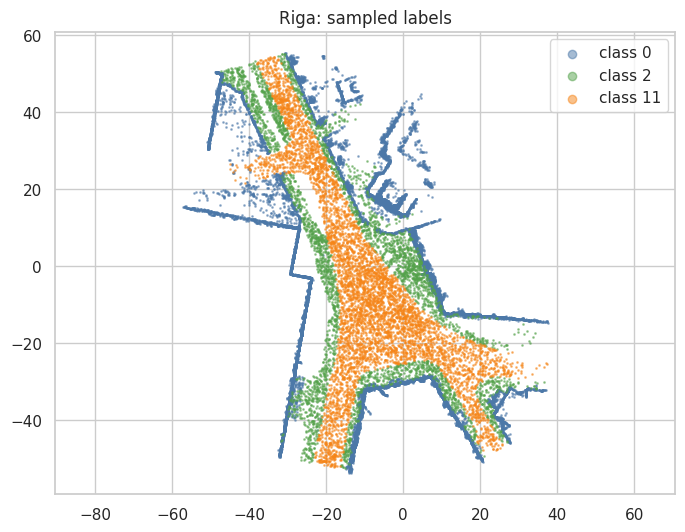

In [6]:
def quick_plot_city_labels(las, city_name, n=50_000):
    xyz = np.column_stack([las.x, las.y, las.z])
    y = np.asarray(las.classification)
    idx = np.random.default_rng(SEED).choice(len(xyz), size=min(n, len(xyz)), replace=False)

    xys = xyz[idx, :2]
    ys = y[idx]
    cmap = {0: "#4c78a8", 2: "#54a24b", 11: "#f58518"}

    plt.figure(figsize=(8, 6))
    for cid, color in cmap.items():
        m = ys == cid
        if m.any():
            plt.scatter(xys[m, 0], xys[m, 1], s=1, c=color, label=f"class {cid}", alpha=0.5)
    plt.title(f"{city_name}: sampled labels")
    plt.axis("equal")
    plt.legend(markerscale=6)
    plt.show()

quick_plot_city_labels(city_las["Riga"], "Riga")

## 4) Build/Load Segmentation Model (geometric segmentation)

For this geometry-first baseline, segmentation is done with voxel superpoints + context graph features (no DL segmentation network yet).

In [7]:
from src.geometry_baseline import (
    compute_local_geometric_features,
    build_superpoints_voxel,
    build_segment_context_features,
    assign_segment_majority_labels,
)

print("Using geometric superpoint segmentation baseline")

Using geometric superpoint segmentation baseline


## 5) Build per-city segment tables

This section runs the complete geometry → segment → label pipeline for each city. The function `build_city_segment_table()` does everything in one call.

### What happens inside the function (step by step)

```
LAS file
    │
    ▼
Step 1: Sample N = 250,000 random points (manageable subset)
    │
    ▼
Step 2: compute_local_geometric_features()
    │  → For each sampled point, look at its 20 nearest neighbours
    │  → Fit a local plane via PCA
    │  → Compute: slope, curvature, roughness, local height std, normal_z
    │
    ▼
Step 3: build_superpoints_voxel()
    │  → Divide 3-D space into 0.6 m voxel cells
    │  → Points in the same cell with similar geometry → merged into one segment
    │  → Each segment now has aggregated features: mean/std of all 5 geometric properties
    │  → Output: segment_id per point + a table with one row per segment
    │
    ▼
Step 4: build_segment_context_features()
    │  → For each segment, find its 8 nearest neighboring segments
    │  → Add their statistics as extra columns (context features)
    │  → This lets the classifier see: "what is next to this segment?"
    │
    ▼
Step 5: assign_segment_majority_labels()
    │  → Each segment contains multiple original points with known IFP labels
    │  → The segment label = whichever class appears most in that segment
    │  → Also computes "purity" = fraction of points matching the majority label
    │
    ▼
Output: one row per segment with geometry + context + label
```

### Why purity matters

If a segment is 60 % road and 40 % pavement, its label is "road" but with low purity. Low-purity segments are noisy training samples — the model is learning from ambiguous boundaries. High-purity segments (90 %+) are reliable.

### Key hyperparameters

| Constant | Value | Effect |
|---|---|---|
| `VOXEL_SIZE` | 0.6 m | Larger = fewer but larger segments; smaller = more segments but fragmented |
| `MIN_POINTS_PER_SEG` | 8 | Segments with fewer than 8 points are discarded as noise |
| `N_CONTEXT_NEIGHBORS` | 8 | How many neighboring segments contribute to context features |

In [8]:
def build_city_segment_table(las, city_name, sample_size=N_SAMPLE_PER_CITY):
    xyz = np.column_stack([las.x, las.y, las.z]).astype(np.float64)
    labels = np.asarray(las.classification)

    sample_idx, feats = compute_local_geometric_features(
        xyz,
        k_neighbors=20,
        sample_size=sample_size,
        random_state=SEED,
        n_jobs=-1,
    )

    sample_pts = xyz[sample_idx]
    sample_labels = labels[sample_idx]

    sp_id, seg_df = build_superpoints_voxel(
        sample_pts,
        feats,
        voxel_size=VOXEL_SIZE,
        min_points=MIN_POINTS_PER_SEG,
    )

    seg_ctx = build_segment_context_features(seg_df, n_neighbors=N_CONTEXT_NEIGHBORS)
    seg_lbl = assign_segment_majority_labels(sp_id, sample_labels)

    out = seg_ctx.merge(seg_lbl, on="segment_id", how="inner")
    out["city"] = city_name
    return out

segment_city_tables = {
    city: build_city_segment_table(las, city)
    for city, las in city_las.items()
}

for city, sdf in segment_city_tables.items():
    print(city, "segments:", len(sdf))

Riga segments: 10565
Utrecht segments: 3729
Vilnius segments: 3481
Warsaw segments: 12711


## 6) Create Segment-level Dataset for Classification

Filter to required classes, align feature columns across cities, and prepare train/test matrices by city.

In [9]:
required = set(TARGET_CLASSES.keys())

segment_city_tables = {
    c: df[df['target_label'].isin(required)].copy()
    for c, df in segment_city_tables.items()
}

protected = {'segment_id', 'target_label', 'target_purity', 'city'}
common_features = sorted(set.intersection(*[
    set([col for col in df.columns if col not in protected])
    for df in segment_city_tables.values()
]))

print("Common segment features:", len(common_features))
print(common_features[:20])

Common segment features: 70
['abs_nz_mean', 'abs_nz_median', 'abs_nz_p90', 'ctx_abs_nz_mean_mean', 'ctx_abs_nz_mean_std', 'ctx_abs_nz_median_mean', 'ctx_abs_nz_median_std', 'ctx_abs_nz_p90_mean', 'ctx_abs_nz_p90_std', 'ctx_curvature_mean_mean', 'ctx_curvature_mean_std', 'ctx_curvature_median_mean', 'ctx_curvature_median_std', 'ctx_curvature_p90_mean', 'ctx_curvature_p90_std', 'ctx_local_height_std_mean_mean', 'ctx_local_height_std_mean_std', 'ctx_local_height_std_median_mean', 'ctx_local_height_std_median_std', 'ctx_local_height_std_p90_mean']


## 7) Leave-One-City-Out (LOCO) training and evaluation

This section is the core evaluation loop. For each of the 4 cities, we hold it out as the test set and train on the other 3.

### Why segment-level LOCO is harder than point-level LOCO

In point-level LOCO (Notebook 4), we test on individual points. Here we test on **segments** — compact groups of geometrically similar points. This is stricter because:
- Each segment must be coherent enough to have a meaningful majority label.
- The classifier receives only segment-level features, not raw XYZ.
- If a segment straddles a road/pavement boundary, its label will be ambiguous regardless of how good the model is.

### How `balanced_subsample` class weighting works

Inside the Random Forest, each tree is built on a **bootstrap sample** (with replacement) of the training data. With `class_weight='balanced_subsample'`, scikit-learn automatically adjusts the sampling probabilities so each class is equally represented in every tree's bootstrap sample. This prevents "other" (which can be 80 %+ of segments) from dominating and pushing all predictions towards "other".

This is different from the manual class-weight calculation in Notebook 4, which computed weights from the actual training distribution.

### Reading the LOCO summary table

| Column | Meaning |
|---|---|
| `held_out_city` | Which city was used as test set |
| `n_train_segments` | Total segments used for training (all other cities combined) |
| `n_test_segments` | Total segments in the test city |
| `balanced_acc` | Average recall across all 3 classes — unaffected by class imbalance |
| `macro_f1` | Average F1 across all 3 classes, each class weighted equally |
| `weighted_f1` | F1 averaged by class *support* — influenced by the dominant "other" class |

A good result is `macro_f1 > 0.6` across most folds. If one city always has the lowest score, it suggests that city's scanner or labelling differs significantly from the others.

### Skipped folds

If a city's segment table lacks any of the three required classes (0, 2, 11), its fold is skipped and reported in a separate table at the bottom. A missing class most commonly means the LAS file has no pavement/road points labelled for that class code — check the class distribution printed in Section 2.

In [ ]:
from sklearn.metrics import f1_score

loco_rows = []
segment_models = {}
skipped_folds = []

# create a function to check for missing classes in a dataframe
def missing_classes(df):
    present = set(df['target_label'].unique())
    return [c for c in CLASS_ORDER if c not in present]

for held_out in segment_city_tables.keys():
    train_cities = [c for c in segment_city_tables.keys() if c != held_out]
    train_df = pd.concat([segment_city_tables[c] for c in train_cities], ignore_index=True)
    test_df = segment_city_tables[held_out].copy()

    missing_in_train = missing_classes(train_df)
    missing_in_test = missing_classes(test_df)
    if missing_in_train or missing_in_test:
        skipped_folds.append({
            'held_out_city': held_out,
            'missing_in_train': missing_in_train,
            'missing_in_test': missing_in_test,
        })
        continue

    X_train = train_df[common_features]
    y_train = train_df['target_label']
    X_test = test_df[common_features]
    y_test = test_df['target_label']

    clf = RandomForestClassifier(
        n_estimators=250,
        random_state=SEED,
        n_jobs=40,
        class_weight='balanced_subsample',
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    segment_models[held_out] = clf

    print('\n' + '=' * 80)
    print(f'Held-out city: {held_out}')
    print(classification_report(y_test, y_pred, labels=CLASS_ORDER, target_names=[TARGET_CLASSES[c] for c in CLASS_ORDER], zero_division=0))

    loco_rows.append({
        'held_out_city': held_out,
        'n_train_segments': len(train_df),
        'n_test_segments': len(test_df),
        'balanced_acc': balanced_accuracy_score(y_test, y_pred),
        'macro_f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

segment_loco_summary = pd.DataFrame(loco_rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)
print('\nSegment-level LOCO summary:')
display(segment_loco_summary)

if skipped_folds:
    print('\nSkipped held-out cities due to missing classes:')
    display(pd.DataFrame(skipped_folds))


Held-out city: Riga
              precision    recall  f1-score   support

       other       0.91      0.96      0.94      3883
    sidewalk       0.44      0.51      0.47       943
      street       0.74      0.55      0.63      1488

    accuracy                           0.80      6314
   macro avg       0.70      0.68      0.68      6314
weighted avg       0.80      0.80      0.80      6314


Held-out city: Warsaw
              precision    recall  f1-score   support

       other       0.00      1.00      0.00         2
    sidewalk       0.74      0.16      0.27      2499
      street       0.67      0.42      0.52      2574

    accuracy                           0.30      5075
   macro avg       0.47      0.53      0.26      5075
weighted avg       0.70      0.30      0.40      5075


Segment-level LOCO summary:


,held_out_city,n_train_segments,n_test_segments,balanced_acc,macro_f1,weighted_f1
0,Riga,9300,6314,0.675824,0.680503,0.796005
1,Warsaw,10539,5075,0.529440,0.263501,0.396262



Skipped held-out cities due to missing classes:


,held_out_city,missing_in_train,missing_in_test
0,Utrecht,[],"[2, 11]"
1,Vilnius,[],[0]


## 8) Run Segment-first, Classify-second Inference Pipeline

Define an end-to-end helper that outputs segment predictions for a single city LAS.

In [14]:
def segment_first_classify_second(las, city_name, clf, feature_cols):
    seg_df = build_city_segment_table(las, city_name, sample_size=N_SAMPLE_PER_CITY)
    seg_df = seg_df[seg_df['target_label'].isin(TARGET_CLASSES.keys())].copy()

    X = seg_df[feature_cols]
    seg_df['pred_label'] = clf.predict(X)
    return seg_df

# Example usage (train on all except Riga, infer on Riga)
train_all_but_riga = pd.concat(
    [segment_city_tables[c] for c in segment_city_tables if c != 'Riga'],
    ignore_index=True,
)
train_all_but_riga = train_all_but_riga[train_all_but_riga['target_label'].isin(TARGET_CLASSES.keys())].copy()

demo_clf = RandomForestClassifier(n_estimators=250, random_state=SEED, n_jobs=40, class_weight='balanced_subsample')
demo_clf.fit(train_all_but_riga[common_features], train_all_but_riga['target_label'])

riga_pred_segments = segment_first_classify_second(city_las['Riga'], 'Riga', demo_clf, common_features)
riga_pred_segments[['segment_id', 'target_label', 'pred_label']].head()

,segment_id,target_label,pred_label
0,0,0,0
1,1,0,0
2,2,0,0
3,3,0,0
4,4,0,0


## 9) Evaluate End-to-end Metrics and Error Cases

Compute core metrics and inspect confusion patterns for segment predictions.

Riga segment-level report (example end-to-end run):
              precision    recall  f1-score   support

       other       0.91      0.96      0.94      3883
    sidewalk       0.44      0.51      0.47       943
      street       0.74      0.55      0.63      1488

    accuracy                           0.80      6314
   macro avg       0.70      0.68      0.68      6314
weighted avg       0.80      0.80      0.80      6314

Balanced accuracy: 0.6758244422142493


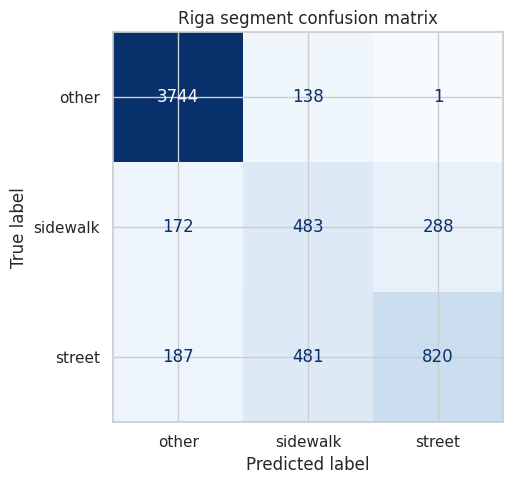

Top error transitions:


,target_label,pred_label,count
5,11,2,481
3,2,11,288
4,11,0,187
2,2,0,172
0,0,2,138
1,0,11,1


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

y_true = riga_pred_segments['target_label']
y_pred = riga_pred_segments['pred_label']

print('Riga segment-level report (example end-to-end run):')
print(classification_report(y_true, y_pred, labels=CLASS_ORDER, target_names=[TARGET_CLASSES[c] for c in CLASS_ORDER], zero_division=0))
print('Balanced accuracy:', balanced_accuracy_score(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[TARGET_CLASSES[c] for c in CLASS_ORDER])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
plt.title('Riga segment confusion matrix')
plt.tight_layout()
plt.show()

error_df = riga_pred_segments[riga_pred_segments['target_label'] != riga_pred_segments['pred_label']]
print('Top error transitions:')
display(error_df.groupby(['target_label', 'pred_label']).size().reset_index(name='count').sort_values('count', ascending=False).head(15))

## For tomorrow:

Look further into the errors between the different classes. Try to solidify the segmentation algoithm